# Решатель

In [391]:
import sympy as sp
from sympy import latex, print_latex
from math import e, lcm, sqrt, sin, cos
import math

h1, h2 = "\n" + "="*50, "\n" + "-"*50

def geo(m):
    if m.shape[0] == 1:
        return f'[{', '.join([str(round(m[0, i], 10)) for i in range(m.shape[1])])}]'
    return f'[{'; '.join([', '.join([str(round(m[j, i], 10)) for i in range(m.shape[1])]) for j in range(m.shape[0])])}]'    

def geolin_matrix(s: str, n: int):
    s = s.replace('−', '-').replace('\u200b', '').split()
    d = sp.MutableDenseMatrix.zeros(n, len(s) // n)
    for i in range(len(s)):
        d[i % n, i // n] = int(s[i])
    return d

def geolin_vector(s: str):
    s = s.replace('−', '-').replace('\u200b', '').split()
    return sp.Matrix([int(x) for x in s])

def mat(inp):
    if isinstance(inp, list):
        return sp.Matrix(inp)
    return inp

In [392]:
def kernel(A):
    A = mat(A)
    K = sp.Matrix.hstack(*A.nullspace())
    display("Исходная матрица A:", A, "Базис ядра K:", K)
    print(geo(K.T))

In [393]:
def image(A):
    A = mat(A)
    display("Изначальная матрица")
    display(A)
    display("Приводим матрицу к ступенчатому виду")
    echelon = A.echelon_form()
    display(echelon)
    # Находим индексы ведущих столбцов
    pivot_cols = []
    for row in echelon.tolist():
        # Ищем первый ненулевой элемент в строке
        for i, elem in enumerate(row):
            if elem != 0:
                if i not in pivot_cols:
                    pivot_cols.append(i)
                break  # Переходим к следующей строке
    
    # Выбираем соответствующие столбцы из исходной матрицы
    basis_columns = [A.col(i) for i in pivot_cols]
    
    display("Формируем матрицу базиса")
    IM = sp.Matrix.hstack(*basis_columns)
    display(IM)
    print(geo(IM.T))

In [394]:
def spectrum(A_input):
    print("Исходная матрица A:")
    A = mat(A_input)
    print(A)

    lamda = sp.symbols('λ')
    print(h1)
    print("Вычисление характеристического полинома det(A - λE)")

    print("\nМатрица A - λE:")
    mat_AE = A - lamda * sp.eye(A.rows)
    print(mat_AE)

    print("\nХарактеристический полином:")
    char_poly = sp.simplify(mat_AE.det())
    char_poly_factored = sp.factor(char_poly)
    print(char_poly)
    print(char_poly_factored)

    print("\nСпектр и алгебраические кратности:")
    roots = sp.roots(char_poly_factored, lamda)
    if not roots:
        roots_list = sp.solve(char_poly, lamda)
        roots = {root: sp.root_multiplicity(char_poly_factored, root) for root in roots_list}
    eigenvalues = sorted(roots.keys(), key=lambda x: [float(sp.re(x)), float(sp.im(x))])
    for eig_val in eigenvalues:
        print(f"λ = {eig_val}, m(λ) = {roots[eig_val]}")
        
        
    print(h1)
    print("Нахождение собственных векторов и нильпотентных операторов")
    eigenvectors = []
    eigenvec_indices = []
    for j, eig_val in enumerate(eigenvalues):
        current_vectors = []
        print(f"\nДля λ = {eig_val}:")
        print(f"Нильпотентный оператор N_λ:")
        N = A - eig_val * sp.eye(A.rows)
        print(N)
        
        print("\nСобственные векторы:")
        nullspace = N.nullspace()
        if nullspace:
            for vec in nullspace:
                eigenvectors.append(vec)
                current_vectors.append(vec)
                eigenvec_indices.append(eig_val)
                print(vec.T)  # Транспонируем для компактного вывода
        else:
            print(f"ERROR: Пустой базис собственных векторов числа {eig_val}!")
        
        alg_mult, geo_mult = roots[eig_val], len(nullspace)
        print(f"0 < g(λ) = {geo_mult} ≤ m(λ) = {alg_mult}")
        
        if alg_mult > geo_mult:
            print("Нужен поиск присоединённых векторов!")
        
        if j + 1 < len(eigenvalues):
            print(h2)

    print(h1)
    print("Матрица перехода C")
    C = sp.Matrix.hstack(*eigenvectors)
    print(C)
    
    if C.cols == C.rows:
        print("\nОбратная матрица C^(-1)")
        print(C.inv())
    return A, C, eigenvec_indices, eigenvalues

def jordan(A, C):
    A, C = mat(A), mat(C)
    if C.cols != C.rows:
        return
    C_inv = C.inv()
    
    print(h1)
    print("Матрица ЖНФ J")
    J = C_inv @ A @ C
    print(J)
    return J

def proectors(C, eigenvec_indices, eigenvalues):
    C = mat(C)
    if C.cols != C.rows:
        return None
    C_inv = C.inv()
    
    print(h1)
    print("Вычисляем проекторы")
    P = {}
    for j, eig_val in enumerate(eigenvalues):
        print(f"\nДля λ = {eig_val}:")
        Pi = []
        for i in range(C.cols):
            if eigenvec_indices[i] == eig_val:
                print(f"Проектор {i} вектора Pi=v*E*f:")
                v, f = C[:,i], C_inv[i,:]
                print('v = ', C[:,i])
                print('f = ', C_inv[i,:])
                PP = v @ f
                print(PP)
                Pi.append(PP)
        print(f"Проектор для λ = {eig_val}")
        P[eig_val] = sp.zeros(C.cols)
        for p in Pi:
            P[eig_val] += p
        print(P[eig_val])
        
        if j + 1 < len(eigenvalues):
            print(h2)  
    return P

# ДЗ 2.1 

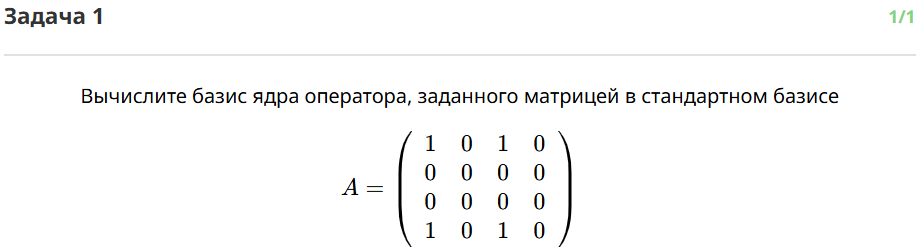

In [395]:
kernel(geolin_matrix("1 0 0 1 ​ 0 0 0 0 ​ 1 0 0 1 ​ 0 0 0 0 ​ ​ ​", 4))

'Исходная матрица A:'

Matrix([
[1, 0, 1, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[1, 0, 1, 0]])

'Базис ядра K:'

Matrix([
[0, -1, 0],
[1,  0, 0],
[0,  1, 0],
[0,  0, 1]])

[0, 1, 0, 0; -1, 0, 1, 0; 0, 0, 0, 1]


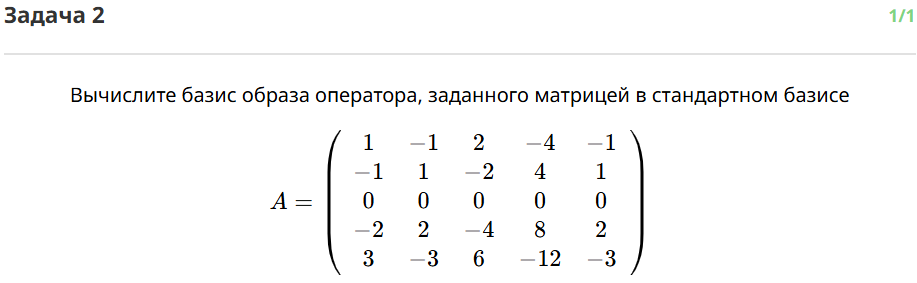

In [396]:
A = [
    [1, -1, 2, -4, -1],
    [-1, 1, -2, 4, 1],
    [0, 0, 0, 0, 0],
    [-2, 2, -4, 8, 2],
    [3, -3, 6, -12, -3]
]

image_basis = image(A)

'Изначальная матрица'

Matrix([
[ 1, -1,  2,  -4, -1],
[-1,  1, -2,   4,  1],
[ 0,  0,  0,   0,  0],
[-2,  2, -4,   8,  2],
[ 3, -3,  6, -12, -3]])

'Приводим матрицу к ступенчатому виду'

Matrix([
[1, -1, 2, -4, -1],
[0,  0, 0,  0,  0],
[0,  0, 0,  0,  0],
[0,  0, 0,  0,  0],
[0,  0, 0,  0,  0]])

'Формируем матрицу базиса'

Matrix([
[ 1],
[-1],
[ 0],
[-2],
[ 3]])

[1, -1, 0, -2, 3]


# ДЗ 2.2

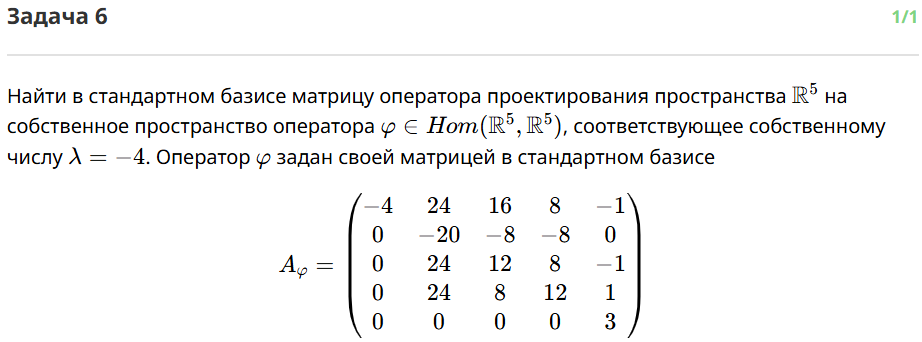

In [397]:
A_input = [
    [-4, 24, 16, 8, -1],
    [0, -20, -8, -8, 0],
    [0, 24, 12, 8, -1],
    [0, 24, 8, 12, 1],
    [0, 0, 0, 0, 3]
]
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

p = P[-4]
display(p)
print(geo(p))

Исходная матрица A:
Matrix([[-4, 24, 16, 8, -1], [0, -20, -8, -8, 0], [0, 24, 12, 8, -1], [0, 24, 8, 12, 1], [0, 0, 0, 0, 3]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 4, 24, 16, 8, -1], [0, -λ - 20, -8, -8, 0], [0, 24, 12 - λ, 8, -1], [0, 24, 8, 12 - λ, 1], [0, 0, 0, 0, 3 - λ]])

Характеристический полином:
-(λ - 3)*(λ + 4)*(λ**3 - 4*λ**2 - 16*λ + 64)
-(λ - 4)**2*(λ - 3)*(λ + 4)**2

Спектр и алгебраические кратности:
λ = -4, m(λ) = 2
λ = 3, m(λ) = 1
λ = 4, m(λ) = 2

Нахождение собственных векторов и нильпотентных операторов

Для λ = -4:
Нильпотентный оператор N_λ:
Matrix([[0, 24, 16, 8, -1], [0, -16, -8, -8, 0], [0, 24, 16, 8, -1], [0, 24, 8, 16, 1], [0, 0, 0, 0, 7]])

Собственные векторы:
Matrix([[1, 0, 0, 0, 0]])
Matrix([[0, -1, 1, 1, 0]])
0 < g(λ) = 2 ≤ m(λ) = 2

--------------------------------------------------

Для λ = 3:
Нильпотентный оператор N_λ:
Matrix([[-7, 24, 16, 8, -1], [0, -23, -8, -8, 0], [0, 24, 9, 8, -1], [0, 24, 8, 9, 1], [

Matrix([
[1, -3, -2, -1, 0],
[0,  3,  1,  1, 0],
[0, -3, -1, -1, 0],
[0, -3, -1, -1, 0],
[0,  0,  0,  0, 0]])

[1, -3, -2, -1, 0; 0, 3, 1, 1, 0; 0, -3, -1, -1, 0; 0, -3, -1, -1, 0; 0, 0, 0, 0, 0]


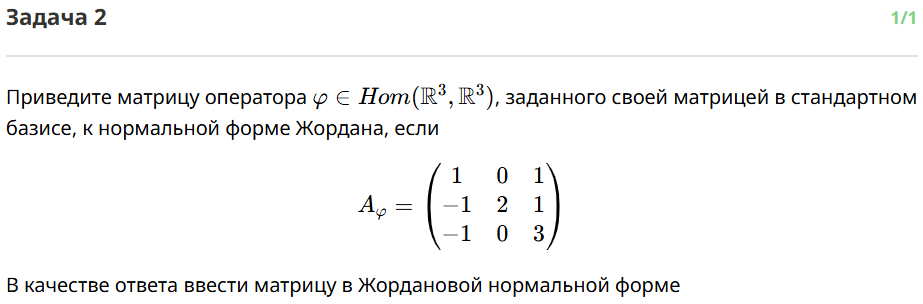

In [398]:
A_input = [
    [1, 0, 1],
    [-1, 2, 1],
    [-1, 0, 3]
]

A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

display(A, C, J)

Исходная матрица A:
Matrix([[1, 0, 1], [-1, 2, 1], [-1, 0, 3]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[1 - λ, 0, 1], [-1, 2 - λ, 1], [-1, 0, 3 - λ]])

Характеристический полином:
-λ**3 + 6*λ**2 - 12*λ + 8
-(λ - 2)**3

Спектр и алгебраические кратности:
λ = 2, m(λ) = 3

Нахождение собственных векторов и нильпотентных операторов

Для λ = 2:
Нильпотентный оператор N_λ:
Matrix([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

Собственные векторы:
Matrix([[0, 1, 0]])
Matrix([[1, 0, 1]])
0 < g(λ) = 2 ≤ m(λ) = 3
Нужен поиск присоединённых векторов!

Матрица перехода C
Matrix([[0, 1], [1, 0], [0, 1]])


Matrix([
[ 1, 0, 1],
[-1, 2, 1],
[-1, 0, 3]])

Matrix([
[0, 1],
[1, 0],
[0, 1]])

None

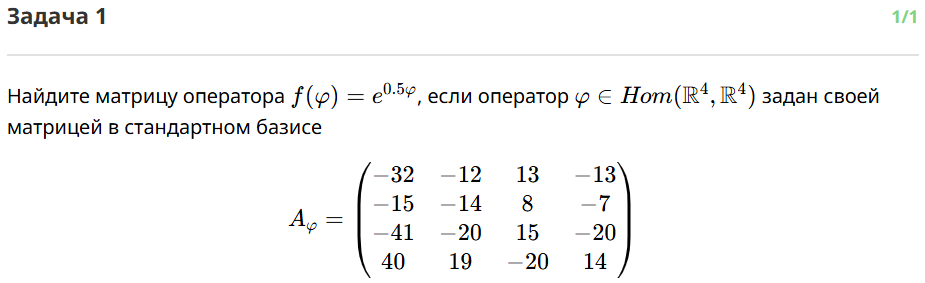

In [399]:
m = sp.Matrix([
    [-32, -12, 13, -13],
    [-15, -14, 8, -7],
    [-41, -20, 15, -20],
    [40, 19, -20, 14]
])
display(m.eigenvals(), m.eigenvects())

display(m.jordan_form())

{1: 1, -6: 3}

[(-6,
  3,
  [Matrix([
   [-1],
   [ 0],
   [-1],
   [ 1]])]),
 (1,
  1,
  [Matrix([
   [-2/3],
   [-1/3],
   [  -1],
   [   1]])])]

(Matrix([
 [-1/2,    1, -1/2, -2/3],
 [   0, -1/2,    1, -1/3],
 [-1/2,  1/2,    0,   -1],
 [ 1/2,   -1,    0,    1]]),
 Matrix([
 [-6,  1,  0, 0],
 [ 0, -6,  1, 0],
 [ 0,  0, -6, 0],
 [ 0,  0,  0, 1]]))

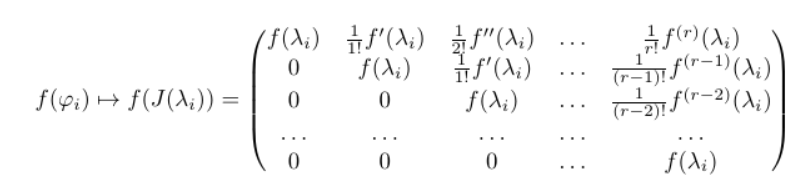

In [400]:
T, J = m.jordan_form()
display(T, J)

F = sp.Matrix([
    [e**(-3), 0.5*e**(-3), 0.125*e**(-3), 0],
    [0, e**(-3), 0.5*e**(-3), 0],
    [0, 0, e**(-3), 0],
    [0, 0, 0, e**(0.5)]
])
display(F)
FF = T @ F @ T.inv()
display(FF)
print(geo(FF))

Matrix([
[-1/2,    1, -1/2, -2/3],
[   0, -1/2,    1, -1/3],
[-1/2,  1/2,    0,   -1],
[ 1/2,   -1,    0,    1]])

Matrix([
[-6,  1,  0, 0],
[ 0, -6,  1, 0],
[ 0,  0, -6, 0],
[ 0,  0,  0, 1]])

Matrix([
[0.049787068367864, 0.024893534183932, 0.00622338354598299,                0],
[                0, 0.049787068367864,   0.024893534183932,                0],
[                0,                 0,   0.049787068367864,                0],
[                0,                 0,                   0, 1.64872127070013]])

Matrix([
[-6.30238605613931, -3.15430471984265,  3.17919825402658,  -3.1729748704806],
[-3.22276193884846, -1.57404066814833,   1.6238277365162, -1.59893420233226],
[-9.57493506335564, -4.77813245635884,  4.85281305891064, -4.77190907281286],
[  9.5500415291717,  4.75323892217491, -4.77813245635884,  4.82169614118073]])

[-6.3023860561, -3.1543047198, 3.1791982540, -3.1729748705; -3.2227619388, -1.5740406681, 1.6238277365, -1.5989342023; -9.5749350634, -4.7781324564, 4.8528130589, -4.7719090728; 9.5500415292, 4.7532389222, -4.7781324564, 4.8216961412]


# ДЗ 2.3

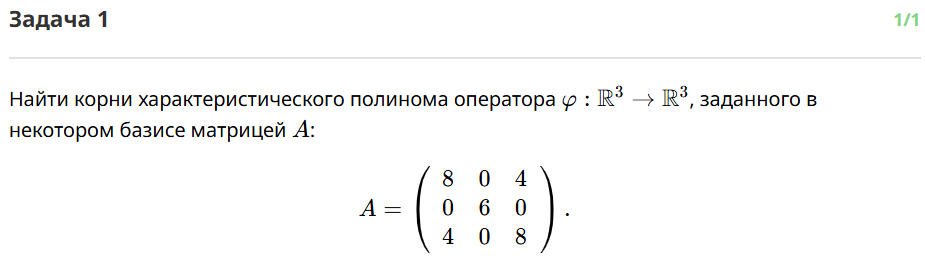

In [401]:
A = geolin_matrix("8 0 4 ​ 0 6 0 ​ 4 0 8", 3)
spectrum(A)

Исходная матрица A:
Matrix([[8, 0, 4], [0, 6, 0], [4, 0, 8]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[8 - λ, 0, 4], [0, 6 - λ, 0], [4, 0, 8 - λ]])

Характеристический полином:
-λ**3 + 22*λ**2 - 144*λ + 288
-(λ - 12)*(λ - 6)*(λ - 4)

Спектр и алгебраические кратности:
λ = 4, m(λ) = 1
λ = 6, m(λ) = 1
λ = 12, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 4:
Нильпотентный оператор N_λ:
Matrix([[4, 0, 4], [0, 2, 0], [4, 0, 4]])

Собственные векторы:
Matrix([[-1, 0, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 6:
Нильпотентный оператор N_λ:
Matrix([[2, 0, 4], [0, 0, 0], [4, 0, 2]])

Собственные векторы:
Matrix([[0, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 12:
Нильпотентный оператор N_λ:
Matrix([[-4, 0, 4], [0, -6, 0], [4, 0, -4]])

Собственные векторы:
Matrix([[1, 0, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
Matrix([[-1

(Matrix([
 [8, 0, 4],
 [0, 6, 0],
 [4, 0, 8]]),
 Matrix([
 [-1, 0, 1],
 [ 0, 1, 0],
 [ 1, 0, 1]]),
 [4, 6, 12],
 [4, 6, 12])

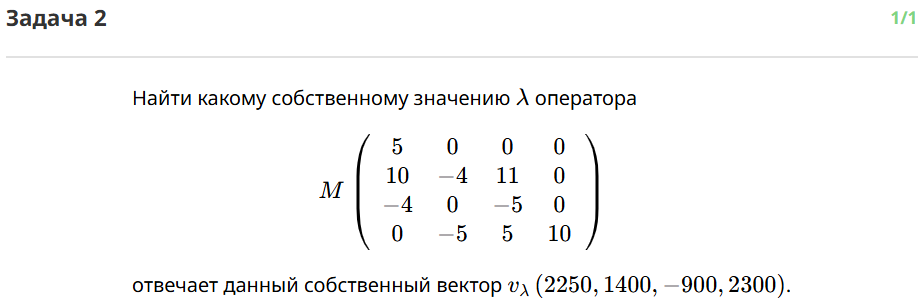

In [402]:
M = geolin_matrix("5 10 −4 0 ​ 0 −4 0 −5 ​ 0 11 −5 5 ​ 0 0 0 10", 4)
v = sp.Matrix([2250, 1400, -900, 2300])
lv = M @ v
display(lv)
print(lv[0] / v[0])

Matrix([
[11250],
[ 7000],
[-4500],
[11500]])

5


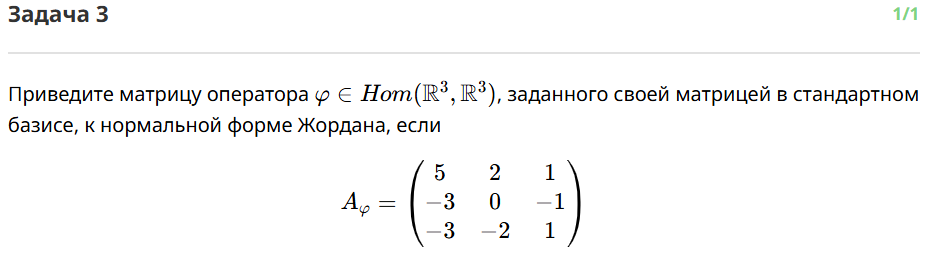

In [403]:
A = geolin_matrix("5 −3 −3 ​ 2 0 −2 ​ 1 −1 1", 3)
display(A)
T, J = A.jordan_form()
display(T, J)

Matrix([
[ 5,  2,  1],
[-3,  0, -1],
[-3, -2,  1]])

Matrix([
[ 3, 1, -2/3],
[-3, 0,    1],
[-3, 0,    0]])

Matrix([
[2, 1, 0],
[0, 2, 0],
[0, 0, 2]])

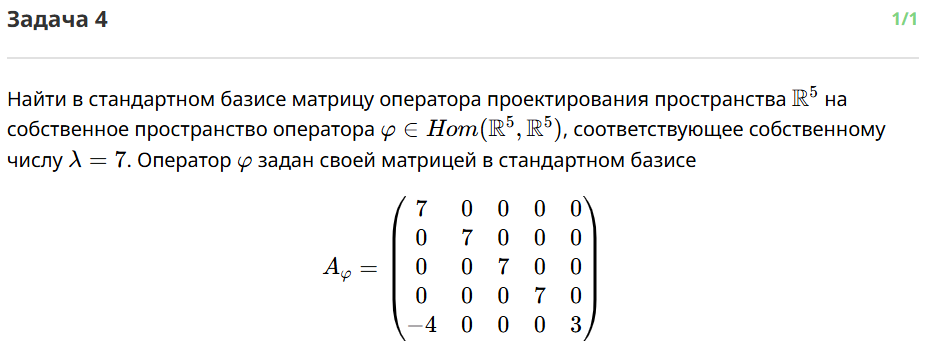

In [404]:
A = geolin_matrix("7 0 0 0 −4 ​ 0 7 0 0 0 ​ 0 0 7 0 0 ​ 0 0 0 7 0 ​ 0 0 0 0 3 ​ ​ ​", 5)

A, C, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

p = P[7]
display(p)
print(geo(p))

Исходная матрица A:
Matrix([[7, 0, 0, 0, 0], [0, 7, 0, 0, 0], [0, 0, 7, 0, 0], [0, 0, 0, 7, 0], [-4, 0, 0, 0, 3]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[7 - λ, 0, 0, 0, 0], [0, 7 - λ, 0, 0, 0], [0, 0, 7 - λ, 0, 0], [0, 0, 0, 7 - λ, 0], [-4, 0, 0, 0, 3 - λ]])

Характеристический полином:
(3 - λ)*(λ - 7)**4
-(λ - 7)**4*(λ - 3)

Спектр и алгебраические кратности:
λ = 3, m(λ) = 1
λ = 7, m(λ) = 4

Нахождение собственных векторов и нильпотентных операторов

Для λ = 3:
Нильпотентный оператор N_λ:
Matrix([[4, 0, 0, 0, 0], [0, 4, 0, 0, 0], [0, 0, 4, 0, 0], [0, 0, 0, 4, 0], [-4, 0, 0, 0, 0]])

Собственные векторы:
Matrix([[0, 0, 0, 0, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 7:
Нильпотентный оператор N_λ:
Matrix([[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [-4, 0, 0, 0, -4]])

Собственные векторы:
Matrix([[0, 1, 0, 0, 0]])
Matrix([[0, 0, 1, 0, 0]])
Matrix([[0, 0, 0, 1, 0]])
Matrix([[

Matrix([
[ 1, 0, 0, 0, 0],
[ 0, 1, 0, 0, 0],
[ 0, 0, 1, 0, 0],
[ 0, 0, 0, 1, 0],
[-1, 0, 0, 0, 0]])

[1, 0, 0, 0, 0; 0, 1, 0, 0, 0; 0, 0, 1, 0, 0; 0, 0, 0, 1, 0; -1, 0, 0, 0, 0]


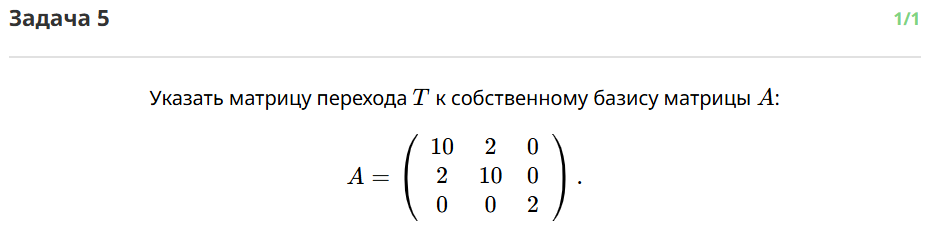

In [405]:
A = geolin_matrix("10 2 0 ​ 2 10 0 ​ 0 0 2", 3)

A, C, eigenvec_indices, eigenvalues = spectrum(A)

display(C)
print(geo(C))

Исходная матрица A:
Matrix([[10, 2, 0], [2, 10, 0], [0, 0, 2]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[10 - λ, 2, 0], [2, 10 - λ, 0], [0, 0, 2 - λ]])

Характеристический полином:
-λ**3 + 22*λ**2 - 136*λ + 192
-(λ - 12)*(λ - 8)*(λ - 2)

Спектр и алгебраические кратности:
λ = 2, m(λ) = 1
λ = 8, m(λ) = 1
λ = 12, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 2:
Нильпотентный оператор N_λ:
Matrix([[8, 2, 0], [2, 8, 0], [0, 0, 0]])

Собственные векторы:
Matrix([[0, 0, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 8:
Нильпотентный оператор N_λ:
Matrix([[2, 2, 0], [2, 2, 0], [0, 0, -6]])

Собственные векторы:
Matrix([[-1, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 12:
Нильпотентный оператор N_λ:
Matrix([[-2, 2, 0], [2, -2, 0], [0, 0, -10]])

Собственные векторы:
Matrix([[1, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
Matri

Matrix([
[0, -1, 1],
[0,  1, 1],
[1,  0, 0]])

[0, -1, 1; 0, 1, 1; 1, 0, 0]


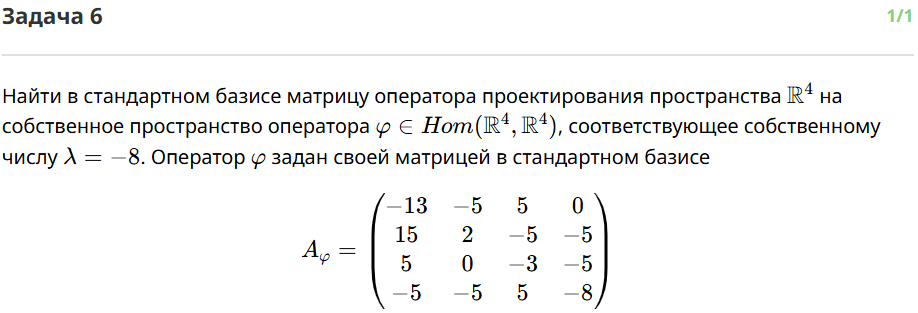

In [406]:
A = geolin_matrix("−13 15 5 −5 ​ −5 2 0 −5 ​ 5 −5 −3 5 ​ 0 −5 −5 −8 ​ ​ ​​", 4)

A, C, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

p = P[-8]
display(p)
print(geo(p))

Исходная матрица A:
Matrix([[-13, -5, 5, 0], [15, 2, -5, -5], [5, 0, -3, -5], [-5, -5, 5, -8]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 13, -5, 5, 0], [15, 2 - λ, -5, -5], [5, 0, -λ - 3, -5], [-5, -5, 5, -λ - 8]])

Характеристический полином:
λ**4 + 22*λ**3 + 169*λ**2 + 528*λ + 576
(λ + 3)**2*(λ + 8)**2

Спектр и алгебраические кратности:
λ = -8, m(λ) = 2
λ = -3, m(λ) = 2

Нахождение собственных векторов и нильпотентных операторов

Для λ = -8:
Нильпотентный оператор N_λ:
Matrix([[-5, -5, 5, 0], [15, 10, -5, -5], [5, 0, 5, -5], [-5, -5, 5, 0]])

Собственные векторы:
Matrix([[-1, 2, 1, 0]])
Matrix([[1, -1, 0, 1]])
0 < g(λ) = 2 ≤ m(λ) = 2

--------------------------------------------------

Для λ = -3:
Нильпотентный оператор N_λ:
Matrix([[-10, -5, 5, 0], [15, 5, -5, -5], [5, 0, 0, -5], [-5, -5, 5, -5]])

Собственные векторы:
Matrix([[0, 1, 1, 0]])
Matrix([[1, -2, 0, 1]])
0 < g(λ) = 2 ≤ m(λ) = 2

Матрица перехода C
Matrix([[-1, 1, 0, 1], [2, -1, 

Matrix([
[ 2,  1, -1, 0],
[-3, -1,  1, 1],
[-1,  0,  0, 1],
[ 1,  1, -1, 1]])

[2, 1, -1, 0; -3, -1, 1, 1; -1, 0, 0, 1; 1, 1, -1, 1]


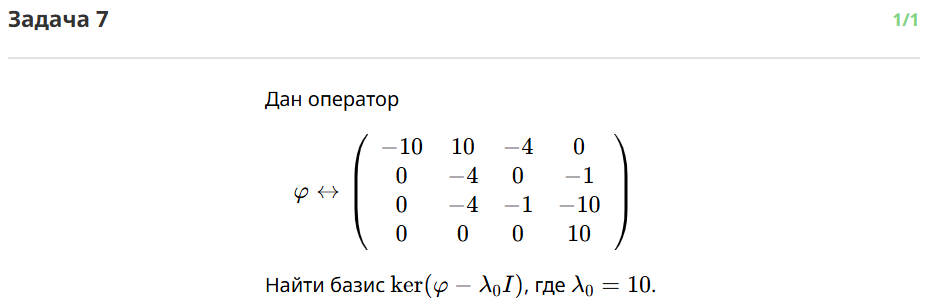

In [407]:
A = geolin_matrix("−10 0 0 0 ​ 10 −4 −4 0 ​ −4 0 −1 0 ​ 0 −1 −10 10", 4)

A, C, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)



Исходная матрица A:
Matrix([[-10, 10, -4, 0], [0, -4, 0, -1], [0, -4, -1, -10], [0, 0, 0, 10]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 10, 10, -4, 0], [0, -λ - 4, 0, -1], [0, -4, -λ - 1, -10], [0, 0, 0, 10 - λ]])

Характеристический полином:
(λ - 10)*(λ + 1)*(λ + 4)*(λ + 10)
(λ - 10)*(λ + 1)*(λ + 4)*(λ + 10)

Спектр и алгебраические кратности:
λ = -10, m(λ) = 1
λ = -4, m(λ) = 1
λ = -1, m(λ) = 1
λ = 10, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = -10:
Нильпотентный оператор N_λ:
Matrix([[0, 10, -4, 0], [0, 6, 0, -1], [0, -4, 9, -10], [0, 0, 0, 20]])

Собственные векторы:
Matrix([[1, 0, 0, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = -4:
Нильпотентный оператор N_λ:
Matrix([[-6, 10, -4, 0], [0, 0, 0, -1], [0, -4, 3, -10], [0, 0, 0, 14]])

Собственные векторы:
Matrix([[7/12, 3/4, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для 

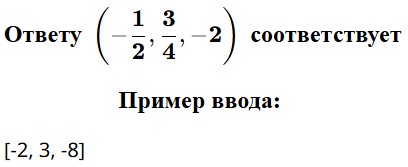

In [408]:
v = [31/220, -1/14, -68/77, 1]

print([x * lcm(220, 14, 77) for x in v])

[217.0, -110.0, -1360.0, 1540]


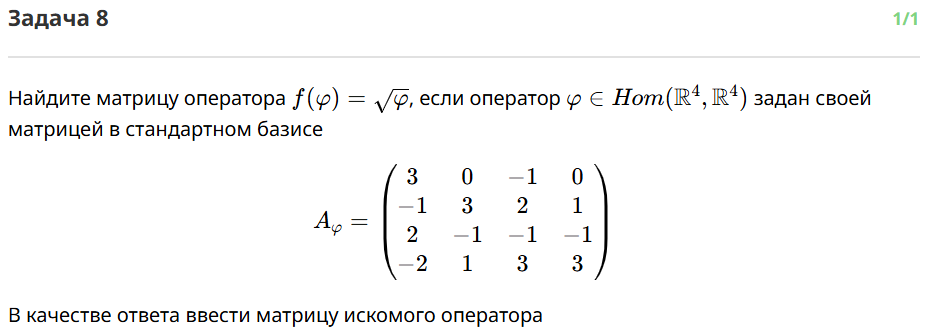

In [409]:
A = geolin_matrix("3 −1 2 −2 ​ 0 3 −1 1 ​ −1 2 −1 3 ​ 0 1 −1 3", 4)

T, J = A.jordan_form()
display(T, J)

F = sp.Matrix([
    [sqrt(2), sqrt(1/8), -1/8/sqrt(2), 0],
    [0, sqrt(2), sqrt(1/8), 0],
    [0, 0, sqrt(2), 0],
    [0, 0, 0, sqrt(2)]
])
display(F)
FF = T @ F @ T.inv()
display(FF)
print(geo(FF))

Matrix([
[-1,  1, 1,  1],
[ 0, -1, 0, -1],
[-1,  2, 0,  1],
[ 1, -2, 0,  0]])

Matrix([
[2, 1, 0, 0],
[0, 2, 1, 0],
[0, 0, 2, 0],
[0, 0, 0, 2]])

Matrix([
[1.4142135623731, 0.353553390593274, -0.0883883476483184,               0],
[              0,   1.4142135623731,   0.353553390593274,               0],
[              0,                 0,     1.4142135623731,               0],
[              0,                 0,                   0, 1.4142135623731]])

Matrix([
[  1.85615530061469, -0.0883883476483185, -0.530330085889911, -0.0883883476483185],
[-0.353553390593274,    1.76776695296637,  0.707106781186548,   0.353553390593274],
[ 0.795495128834866,  -0.441941738241592,  0.176776695296637,  -0.441941738241592],
[-0.795495128834866,   0.441941738241592,   1.23743686707646,    1.85615530061469]])

[1.8561553006, -0.0883883476, -0.5303300859, -0.0883883476; -0.3535533906, 1.7677669530, 0.7071067812, 0.3535533906; 0.7954951288, -0.4419417382, 0.1767766953, -0.4419417382; -0.7954951288, 0.4419417382, 1.2374368671, 1.8561553006]


# КР 2

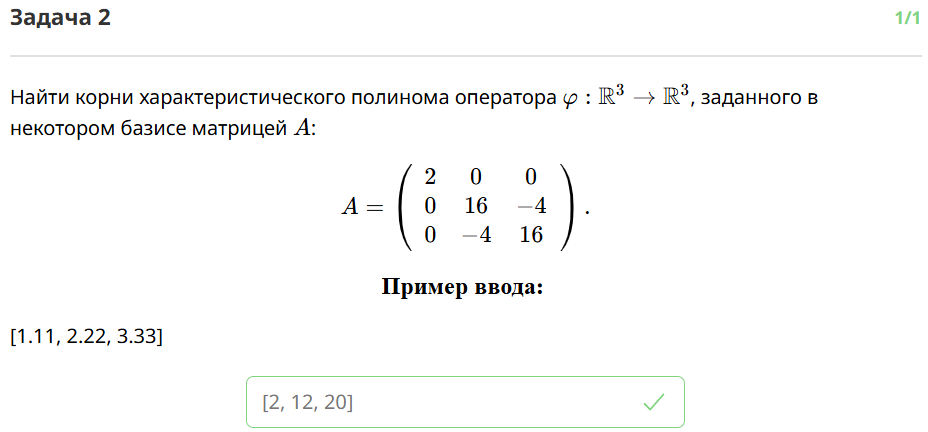

In [410]:
A = geolin_matrix("2 0 0 ​ 0 16 −4 ​ 0 −4 16", 3)

A, C, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

Исходная матрица A:
Matrix([[2, 0, 0], [0, 16, -4], [0, -4, 16]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[2 - λ, 0, 0], [0, 16 - λ, -4], [0, -4, 16 - λ]])

Характеристический полином:
-λ**3 + 34*λ**2 - 304*λ + 480
-(λ - 20)*(λ - 12)*(λ - 2)

Спектр и алгебраические кратности:
λ = 2, m(λ) = 1
λ = 12, m(λ) = 1
λ = 20, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 2:
Нильпотентный оператор N_λ:
Matrix([[0, 0, 0], [0, 14, -4], [0, -4, 14]])

Собственные векторы:
Matrix([[1, 0, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 12:
Нильпотентный оператор N_λ:
Matrix([[-10, 0, 0], [0, 4, -4], [0, -4, 4]])

Собственные векторы:
Matrix([[0, 1, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 20:
Нильпотентный оператор N_λ:
Matrix([[-18, 0, 0], [0, -4, -4], [0, -4, -4]])

Собственные векторы:
Matrix([[0, -1, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица 

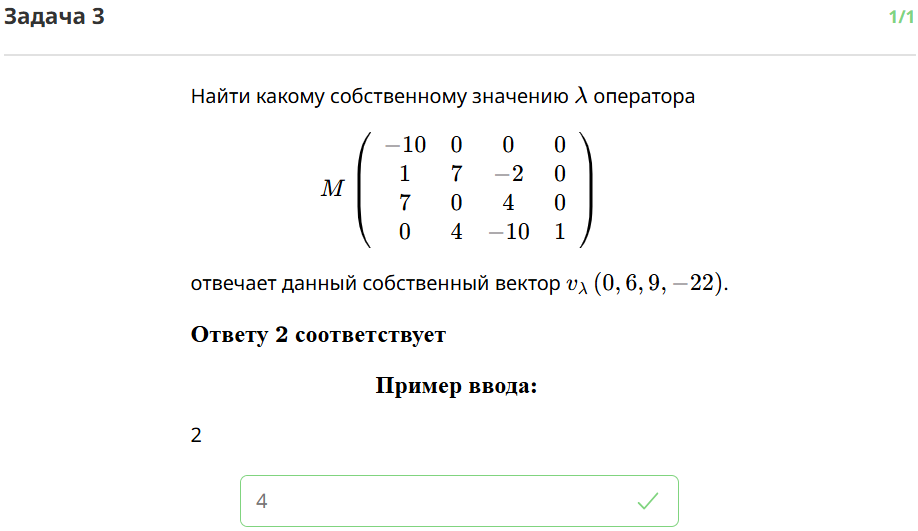

In [411]:
M = geolin_matrix("−10 1 7 0 ​ 0 7 0 4 ​ 0 −2 4 −10 ​ 0 0 0 1 ​ ​ ​", 4)
v = sp.Matrix([0,6,9,-22])
lv = M @ v
display(lv)
print(lv[1] / v[1])

Matrix([
[  0],
[ 24],
[ 36],
[-88]])

4


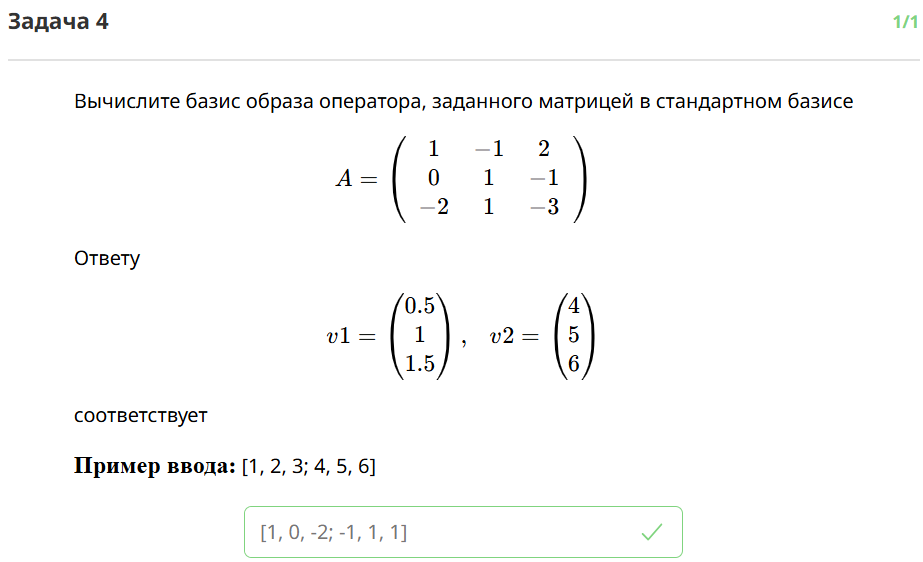

In [412]:
image(geolin_matrix("1 0 −2 ​ −1 1 1 ​ 2 −1 −3 ​ ​ ​", 3))

'Изначальная матрица'

Matrix([
[ 1, -1,  2],
[ 0,  1, -1],
[-2,  1, -3]])

'Приводим матрицу к ступенчатому виду'

Matrix([
[1, -1,  2],
[0,  1, -1],
[0,  0,  0]])

'Формируем матрицу базиса'

Matrix([
[ 1, -1],
[ 0,  1],
[-2,  1]])

[1, 0, -2; -1, 1, 1]


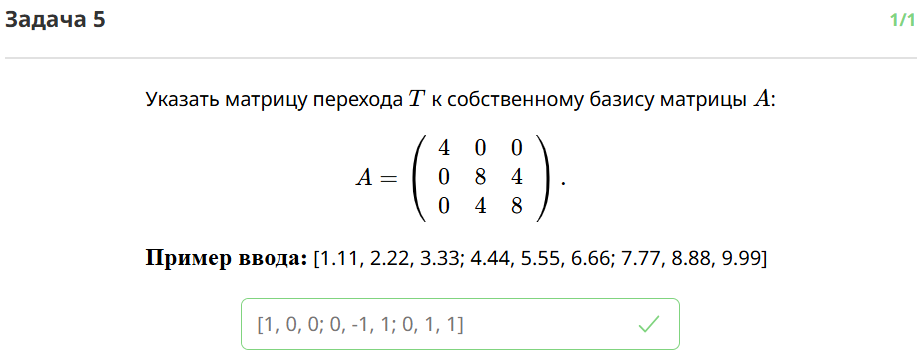

In [413]:
A = geolin_matrix("4 0 0 ​ 0 8 4 ​ 0 4 8", 3)

A, T, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, T)
P = proectors(T, eigenvec_indices, eigenvalues)

display(T)
print(geo(T))

display(A.jordan_form())

Исходная матрица A:
Matrix([[4, 0, 0], [0, 8, 4], [0, 4, 8]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[4 - λ, 0, 0], [0, 8 - λ, 4], [0, 4, 8 - λ]])

Характеристический полином:
-λ**3 + 20*λ**2 - 112*λ + 192
-(λ - 12)*(λ - 4)**2

Спектр и алгебраические кратности:
λ = 4, m(λ) = 2
λ = 12, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 4:
Нильпотентный оператор N_λ:
Matrix([[0, 0, 0], [0, 4, 4], [0, 4, 4]])

Собственные векторы:
Matrix([[1, 0, 0]])
Matrix([[0, -1, 1]])
0 < g(λ) = 2 ≤ m(λ) = 2

--------------------------------------------------

Для λ = 12:
Нильпотентный оператор N_λ:
Matrix([[-8, 0, 0], [0, -4, 4], [0, 4, -4]])

Собственные векторы:
Matrix([[0, 1, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
Matrix([[1, 0, 0], [0, -1, 1], [0, 1, 1]])

Обратная матрица C^(-1)
Matrix([[1, 0, 0], [0, -1/2, 1/2], [0, 1/2, 1/2]])

Матрица ЖНФ J
Matrix([[4, 0, 0], [0, 4, 0], [0, 0, 12]])

Вычисляем проекторы

Для λ = 4:
Пр

Matrix([
[1,  0, 0],
[0, -1, 1],
[0,  1, 1]])

[1, 0, 0; 0, -1, 1; 0, 1, 1]


(Matrix([
 [1,  0, 0],
 [0, -1, 1],
 [0,  1, 1]]),
 Matrix([
 [4, 0,  0],
 [0, 4,  0],
 [0, 0, 12]]))

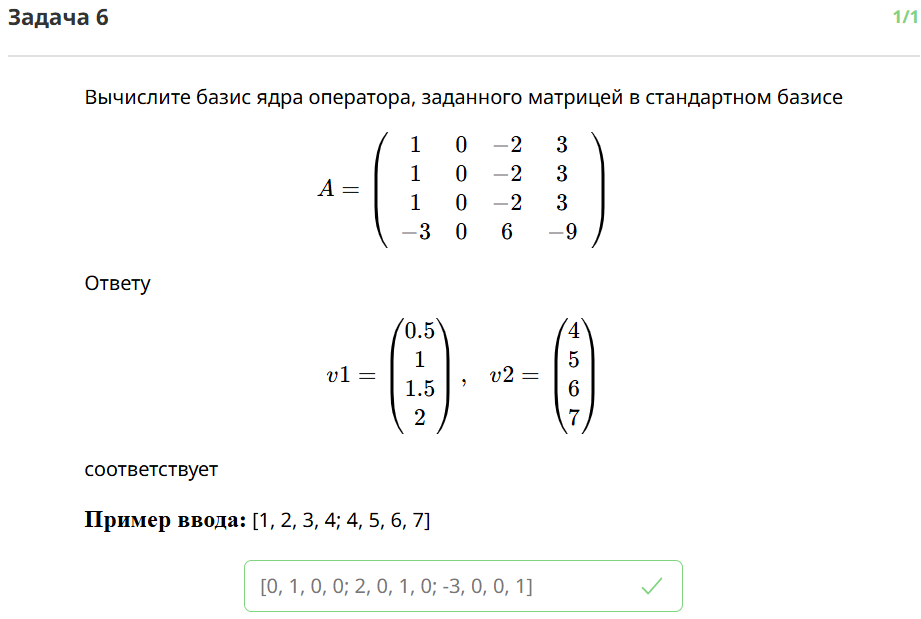

In [414]:
kernel(geolin_matrix("1 1 1 −3 ​ 0 0 0 0 ​ −2 −2 −2 6 ​ 3 3 3 −9", 4))

'Исходная матрица A:'

Matrix([
[ 1, 0, -2,  3],
[ 1, 0, -2,  3],
[ 1, 0, -2,  3],
[-3, 0,  6, -9]])

'Базис ядра K:'

Matrix([
[0, 2, -3],
[1, 0,  0],
[0, 1,  0],
[0, 0,  1]])

[0, 1, 0, 0; 2, 0, 1, 0; -3, 0, 0, 1]


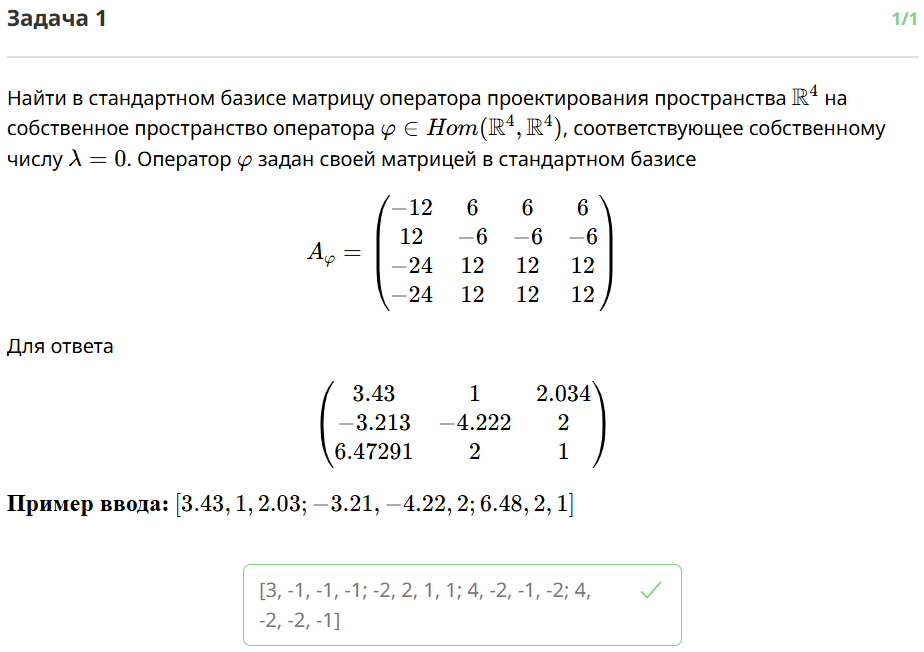

In [415]:
A_input = geolin_matrix("−12 12 −24 −24 ​ 6 −6 12 12 ​ 6 −6 12 12 ​ 6 −6 12 12", 4)
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

p = P[0]
display(p)
print(geo(p))

Исходная матрица A:
Matrix([[-12, 6, 6, 6], [12, -6, -6, -6], [-24, 12, 12, 12], [-24, 12, 12, 12]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 12, 6, 6, 6], [12, -λ - 6, -6, -6], [-24, 12, 12 - λ, 12], [-24, 12, 12, 12 - λ]])

Характеристический полином:
λ**3*(λ - 6)
λ**3*(λ - 6)

Спектр и алгебраические кратности:
λ = 0, m(λ) = 3
λ = 6, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 0:
Нильпотентный оператор N_λ:
Matrix([[-12, 6, 6, 6], [12, -6, -6, -6], [-24, 12, 12, 12], [-24, 12, 12, 12]])

Собственные векторы:
Matrix([[1/2, 1, 0, 0]])
Matrix([[1/2, 0, 1, 0]])
Matrix([[1/2, 0, 0, 1]])
0 < g(λ) = 3 ≤ m(λ) = 3

--------------------------------------------------

Для λ = 6:
Нильпотентный оператор N_λ:
Matrix([[-18, 6, 6, 6], [12, -12, -6, -6], [-24, 12, 6, 12], [-24, 12, 12, 6]])

Собственные векторы:
Matrix([[1/2, -1/2, 1, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
Matrix([[1/2, 1/2, 1/2, 1/2], [1, 0, 0, -

Matrix([
[ 3, -1, -1, -1],
[-2,  2,  1,  1],
[ 4, -2, -1, -2],
[ 4, -2, -2, -1]])

[3, -1, -1, -1; -2, 2, 1, 1; 4, -2, -1, -2; 4, -2, -2, -1]


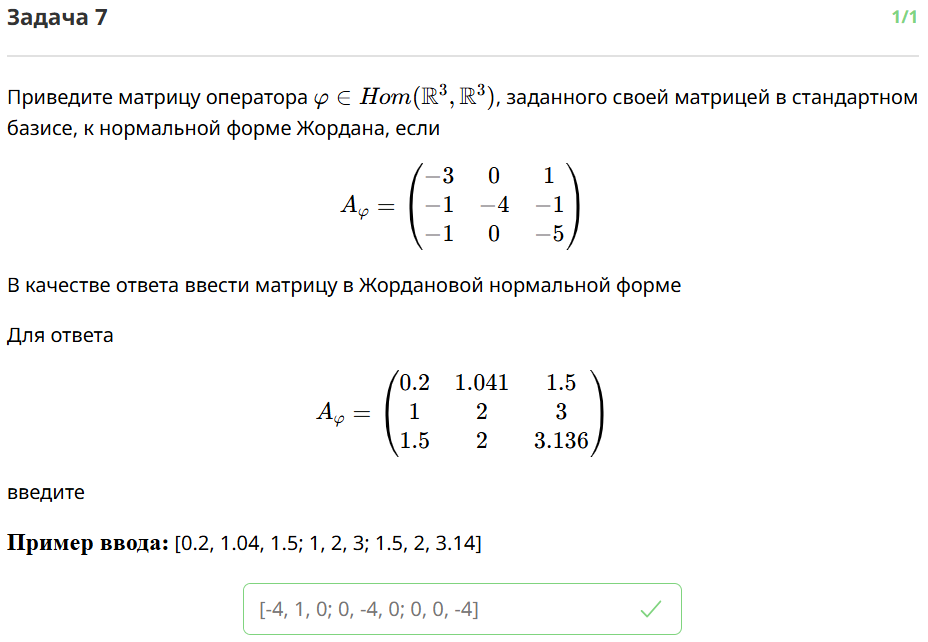

In [416]:
A_input = geolin_matrix("−3 −1 −1 ​ 0 −4 0 ​ 1 −1 −5", 3)
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
# J = jordan(A, C)
# P = proectors(C, eigenvec_indices, eigenvalues)

T, J = A.jordan_form()
display(T, J)
print(geo(J))

Исходная матрица A:
Matrix([[-3, 0, 1], [-1, -4, -1], [-1, 0, -5]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 3, 0, 1], [-1, -λ - 4, -1], [-1, 0, -λ - 5]])

Характеристический полином:
-λ**3 - 12*λ**2 - 48*λ - 64
-(λ + 4)**3

Спектр и алгебраические кратности:
λ = -4, m(λ) = 3

Нахождение собственных векторов и нильпотентных операторов

Для λ = -4:
Нильпотентный оператор N_λ:
Matrix([[1, 0, 1], [-1, 0, -1], [-1, 0, -1]])

Собственные векторы:
Matrix([[0, 1, 0]])
Matrix([[-1, 0, 1]])
0 < g(λ) = 2 ≤ m(λ) = 3
Нужен поиск присоединённых векторов!

Матрица перехода C
Matrix([[0, -1], [1, 0], [0, 1]])


Matrix([
[ 1, 1, 0],
[-1, 0, 1],
[-1, 0, 0]])

Matrix([
[-4,  1,  0],
[ 0, -4,  0],
[ 0,  0, -4]])

[-4, 1, 0; 0, -4, 0; 0, 0, -4]


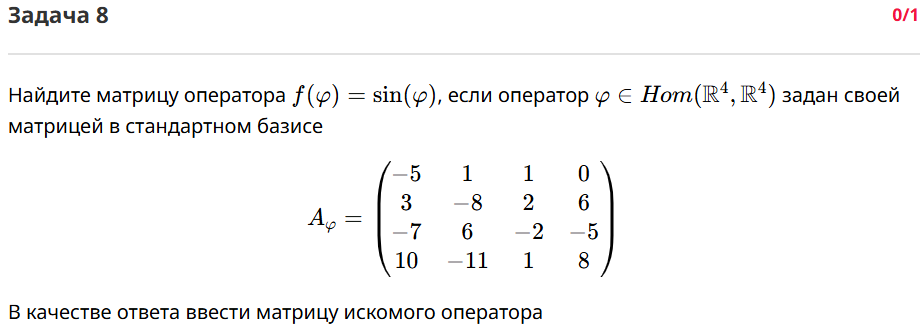

In [417]:
A_input = geolin_matrix("−5 3 −7 10 ​ 1 −8 6 −11 ​ 1 2 −2 1 ​ 0 6 −5 8", 4)
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
# J = jordan(A, C)
# P = proectors(C, eigenvec_indices, eigenvalues)

T, J = A.jordan_form()
display(T, J)

Исходная матрица A:
Matrix([[-5, 1, 1, 0], [3, -8, 2, 6], [-7, 6, -2, -5], [10, -11, 1, 8]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 5, 1, 1, 0], [3, -λ - 8, 2, 6], [-7, 6, -λ - 2, -5], [10, -11, 1, 8 - λ]])

Характеристический полином:
λ**4 + 7*λ**3 + 9*λ**2 - 27*λ - 54
(λ - 2)*(λ + 3)**3

Спектр и алгебраические кратности:
λ = -3, m(λ) = 3
λ = 2, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = -3:
Нильпотентный оператор N_λ:
Matrix([[-2, 1, 1, 0], [3, -5, 2, 6], [-7, 6, 1, -5], [10, -11, 1, 11]])

Собственные векторы:
Matrix([[1, 1, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 3
Нужен поиск присоединённых векторов!

--------------------------------------------------

Для λ = 2:
Нильпотентный оператор N_λ:
Matrix([[-7, 1, 1, 0], [3, -10, 2, 6], [-7, 6, -4, -5], [10, -11, 1, 6]])

Собственные векторы:
Matrix([[0, 1/2, -1/2, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
Matrix([[1, 0], [1, 1/2], [1, -1/2], [0, 1]])


Matrix([
[-1, -1, 1,    0],
[-1, -2, 1,  1/2],
[-1, -1, 0, -1/2],
[ 0, -1, 0,    1]])

Matrix([
[-3,  1,  0, 0],
[ 0, -3,  1, 0],
[ 0,  0, -3, 0],
[ 0,  0,  0, 2]])

In [418]:
N = sp.Matrix([
    [-2, 1, 1, 0],
    [3, -5, 2, 6],
    [-7, 6, 1, -5],
    [10, -11, 1, 11]
])
a, b = sp.symbols("α β")
B = sp.Matrix([a + b, a + 2*b, a + b, b])

sp.linsolve(N.row_join(B))

{(tau0 - β, tau0 + α - β, tau0, α)}

In [419]:
C = sp.Matrix([
    [1, 1, -1, 0],
    [1, 2, -1, 1/2],
    [1, 1, 0, -1/2],
    [0, 1, 0, 1]
])

display(C.inv() @ A @ C)

Matrix([
[-3.0,  1.0,    0,   0],
[   0, -3.0,  1.0,   0],
[   0,    0, -3.0,   0],
[   0,    0,    0, 2.0]])

In [420]:
T, J = A.jordan_form()

FJ = sp.Matrix([
    [sin(-3), cos(-3), -0.5*sin(-3), 0],
    [0, sin(-3), cos(-3), 0],
    [0, 0, sin(-3), 0],
    [0, 0, 0, sin(2)]
])

display(FJ)
F = T @ FJ @ T.inv()
display(F)
print(geo(F))

Matrix([
[-0.141120008059867, -0.989992496600445, 0.0705600040299336,                 0],
[                 0, -0.141120008059867, -0.989992496600445,                 0],
[                 0,                  0, -0.141120008059867,                 0],
[                 0,                  0,                  0, 0.909297426825682]])

Matrix([
[ 1.83886498514102,   -1.06055250063038, -0.919432492570512, 0.0705600040299335],
[ 3.03040242808644,   -1.26209744697535,  -1.90942498917096,  0.130984942315037],
[0.929567558315342, -0.0101350657448299,  -1.06055250063038, -0.979857430855615],
[  2.1008348697711,   -1.11084237317065, -0.989992496600445,  0.969722365110785]])

[1.8388649851, -1.0605525006, -0.9194324926, 0.0705600040; 3.0304024281, -1.2620974470, -1.9094249892, 0.1309849423; 0.9295675583, -0.0101350657, -1.0605525006, -0.9798574309; 2.1008348698, -1.1108423732, -0.9899924966, 0.9697223651]
